# 1. Data Processing

- Install and import libriaries
- Load the dataset
- Preview the data
- Format and standardize the data.

In [0]:
dbutils.library.restartPython()

In [0]:
# Importing pandas for data analysis and manipulation (handling data frames)
import pandas as pd

# Used for array manipulation and matrix operations
import numpy as np

# Importing matplotlib for creating visualizations
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm

# Import seaborn for statistical data visualization
import seaborn as sns

# Use choropleth maps 
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Import MinMaxScaler to normalize feature to 0-1 range
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from scipy.stats import ttest_ind

# Import the 'us' library to access U.S. state information (names, abbreviations, FIPS codes, etc.)
import us

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [0]:
# Read dataset from Databricks Catalog
realtor_data_spark = spark.read.table("workspace.default.realtor_data_zip")
df = realtor_data_spark.toPandas()

print("Raw data:")
display(df.head())
display(df.info())

print("\n")

# Convert it to a pandas DataFrame for downstream EDA and modeling
def load_data():
    return spark.read.table("workspace.default.realtor_data_zip").toPandas()
    
# Load the dataset
df = load_data()

# Convert numeric columns to integers, even if it contains messy or non-numeric values
cols_to_int = ['brokered_by', 'price', 'bed', 'bath', 'street', 'zip_code', 'house_size']
for col in cols_to_int:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    
# Fill the string-type columns with "Unknown" where values are NaN 
cols_to_fill = ['status', 'city', 'state']
df[cols_to_fill] = df[cols_to_fill].fillna("Unknown")

# Convert to datetime
df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')

# Fill missing values with placeholder
placeholder_date = pd.to_datetime("1900-01-01")
plot_df = df[df['prev_sold_date'] != placeholder_date]

# Fill NaN values in the float-type column with 0.0
df['acre_lot'] = df['acre_lot'].fillna(0.0)

print("Data standardization:")
display(df.head())
display(df.iloc[163364:163388])
display(df.iloc[[530530]])

Raw data:


brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,null
52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,null
103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,null
31239.0,for_sale,145000.0,4.0,2.0,0.1,1947675.0,Ponce,Puerto Rico,731.0,1800.0,null
34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,null,null


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   brokered_by     1047537 non-null  float64
 1   status          1048575 non-null  object 
 2   price           1047485 non-null  float64
 3   bed             738569 non-null   float64
 4   bath            723607 non-null   float64
 5   acre_lot        870247 non-null   float64
 6   street          1041799 non-null  float64
 7   city            1047715 non-null  object 
 8   state           1048568 non-null  object 
 9   zip_code        1048416 non-null  float64
 10  house_size      683689 non-null   float64
 11  prev_sold_date  497886 non-null   object 
dtypes: float64(8), object(4)
memory usage: 96.0+ MB


Data standardization:


brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
103378,for_sale,105000,3,2,0.12,1962661,Adjuntas,Puerto Rico,601,920,null
52707,for_sale,80000,4,2,0.08,1902874,Adjuntas,Puerto Rico,601,1527,null
103379,for_sale,67000,2,1,0.15,1404990,Juana Diaz,Puerto Rico,795,748,null
31239,for_sale,145000,4,2,0.1,1947675,Ponce,Puerto Rico,731,1800,null
34632,for_sale,65000,6,2,0.05,331151,Mayaguez,Puerto Rico,680,0,null


brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
79270,for_sale,144500,2,2,0.08,336787,Pittsburgh,Pennsylvania,15216,0,2014-11-20T00:00:00.000Z
19512,for_sale,330000,4,3,0.37,727797,Elizabeth,Pennsylvania,15037,0,2007-10-03T00:00:00.000Z
22611,for_sale,259900,3,2,0.5,1050836,Canonsburg,Pennsylvania,15317,1560,2014-07-23T00:00:00.000Z
22611,for_sale,204900,3,2,0.0,1082904,Homestead,Pennsylvania,15120,0,2021-01-06T00:00:00.000Z
10705,for_sale,148000,0,0,0.09,236400,Pittsburgh,Pennsylvania,15227,0,2002-04-29T00:00:00.000Z
51500,for_sale,39900,2,1,0.01,539121,McKeesport,Pennsylvania,15132,0,2004-10-29T00:00:00.000Z
30750,for_sale,299900,4,3,0.1,213868,Pittsburgh,Pennsylvania,15216,1888,1987-05-20T00:00:00.000Z
83644,for_sale,269900,3,2,0.41,158722,Canonsburg,Pennsylvania,15317,1262,2017-04-06T00:00:00.000Z
22611,for_sale,270000,3,3,0.18,714188,Pittsburgh,Pennsylvania,15226,1440,2018-06-22T00:00:00.000Z
110141,for_sale,179900,0,0,0.06,930393,Pittsburgh,Pennsylvania,15227,0,2021-08-05T00:00:00.000Z


brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
11761,ready_to_build,204990,3,0,0.0,828031,Binder,Unknown,96999,1273,null


For further Metropolitan Statistical Area (MSA) analysis, related datasets were merged with consistent data types to ensure smooth processing.

zipcode_FIPS_cbsa_crosswalk_2015.csv includes the following columns:
- zipcode
- FIPS
- CountyName
- cbsacode
- cbsatitle
- metromicro

OMB_cbsa_2015.csv provides supplementary information and includes:
- CBSA Code
- CBSA Title
- Metropolitan/Micropolitan Statistical Area

To fill in the missing cbsatitle and metromicro fields in zipcode_FIPS_cbsa_crosswalk_2015.csv, a merge was performed using the cbsacode as the key.

Challenge: Dataset Alignment and Cross-Framework Integration

To successfully merge multiple datasets, it was critical to ensure proper alignment of shared dimensions (e.g., CBSA code) across sources.

One of the main challenges was handling messy official data, where column headers were not standardized and appeared in non-default rows. This required programmatically realigning headers and cleaning key fields before performing joins.

Additionally, the workflow needed to seamlessly switch between Spark DataFrames and pandas DataFrames depending on the task.

This hybrid approach ensured both scalability and analytical flexibility throughout the pipeline.

In [0]:
# Load data
crosswalk  = spark.read.table("workspace.default.zipcode_FIPS_cbsa_crosswalk_2015").toPandas()
cbsa_names  = spark.read.table("workspace.default.OMB_cbsa_2015").toPandas()

# Find the real header (The row 1, index=1)
cbsa_names.columns = cbsa_names.iloc[1]

# Drop the useless columns at the beginning.
cbsa_names = cbsa_names.iloc[3:].reset_index(drop=True)

print(cbsa_names.columns)



Index(['CBSA Code', 'Metropolitan Division Code', 'CSA Code', 'CBSA Title',
       'Metropolitan/Micropolitan Statistical Area',
       'Metropolitan Division Title', 'CSA Title', 'County/County Equivalent',
       'State Name', 'FIPS State Code', 'FIPS County Code',
       'Central/Outlying County'],
      dtype='object', name=1)


In [0]:
# Rename columns in cbsa_names dataframe to shorter, consistent lowercase names
cbsa_names = cbsa_names.rename(columns={
    'CBSA Code': 'cbsacode',
    'CBSA Title': 'cbsatitle',
    'Metropolitan/Micropolitan Statistical Area': 'metromicro'
})

# Ensure data type consistency
crosswalk['cbsacode'] = crosswalk['cbsacode'].astype(str).str.strip()
cbsa_names['cbsacode'] = cbsa_names['cbsacode'].astype(str).str.strip()

# To remedy the special value '99999', mark it as unknown
crosswalk.loc[crosswalk['cbsacode'] == '99999', ['cbsatitle', 'metromicro']] = ['No CBSA', 'Unknown']

# Merge crosswalk and cbsa_names, and do a left merge based on cbsacode (mainly crosswalk)
crosswalk_full = pd.merge(crosswalk, cbsa_names, on='cbsacode', how='left', suffixes=('_orig', ''))

In [0]:
# First make sure df['zip_code'] is a 5-code string format
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5).str.strip()

# Make sure crosswalk_full['zipcode'] is in the same format
crosswalk_full['zipcode'] = crosswalk_full['zipcode'].astype(str).str.zfill(5).str.strip()

# Merge with df, and match zip_code to crosswalk_full’s zipcode
df_merged = df.merge(
    crosswalk_full[['zipcode', 'cbsatitle', 'metromicro']],
    left_on='zip_code',
    right_on='zipcode',
    how='left'
).drop(columns=['zipcode'])  # If no need the 'zipcode' field after merging, delete it

# Check the output
print(df_merged[['zip_code', 'cbsatitle', 'metromicro']].head(10))

  zip_code     cbsatitle                     metromicro
0    00601  Adjuntas, PR  Micropolitan Statistical Area
1    00601  Adjuntas, PR  Micropolitan Statistical Area
2    00795     Ponce, PR  Metropolitan Statistical Area
3    00795     Ponce, PR  Metropolitan Statistical Area
4    00795     Ponce, PR  Metropolitan Statistical Area
5    00795     Ponce, PR  Metropolitan Statistical Area
6    00795     Ponce, PR  Metropolitan Statistical Area
7    00795     Ponce, PR  Metropolitan Statistical Area
8    00795     Ponce, PR  Metropolitan Statistical Area
9    00731     Ponce, PR  Metropolitan Statistical Area


In [0]:
print(df['price'].describe())

count    1.048575e+06
mean     4.770015e+05
std      2.772817e+06
min      0.000000e+00
25%      1.199000e+05
50%      2.750000e+05
75%      4.809000e+05
max      2.147484e+09
Name: price, dtype: float64


Summary of the distribution of the price column

Outlier Dataset: The mean is much higher than the median due to extreme high values (like $2.1 billion), pulling the average up. This suggests right-skewed data (most homes are cheaper, but a few are very expensive).

Standard Deviation is Large: A standard deviation of 2.77 million is huge compared to the mean. It shows prices vary dramatically, from 0 to over 2 billion.

Filter Data: Cap or investigate prices over $5 million

# 2. EDA and Visualization

### 2-1. Time Series Subplot

2-1-1. Sales count over the past five years: Displays historical housing sales data with the year on the x-axis and the number of properties sold on the y-axis.

2-1-2. Average price over the past five years: Displays the date on the x-axis and the average price (normalised) on the y-axis.

Interpret the normalised price values

0.0 = cheapest price in the filtered set (i.e., $10,000)

0.6 = a price that is 60% of the way between 10,000 and 5,000,000 (roughly $3,000,000)

1.0 = most expensive price in the filtered set (i.e., $5,000,000)

The historical average normalised price shows four distinct peaks above 0.5, indicating that on those day, the average property prices were higher than approximately 2.5 million. Given the filtered price range (10,000 to 5,000,000), a normalised value above 0.5 refects days with the average sale prices leaned toward the upper end of the market.

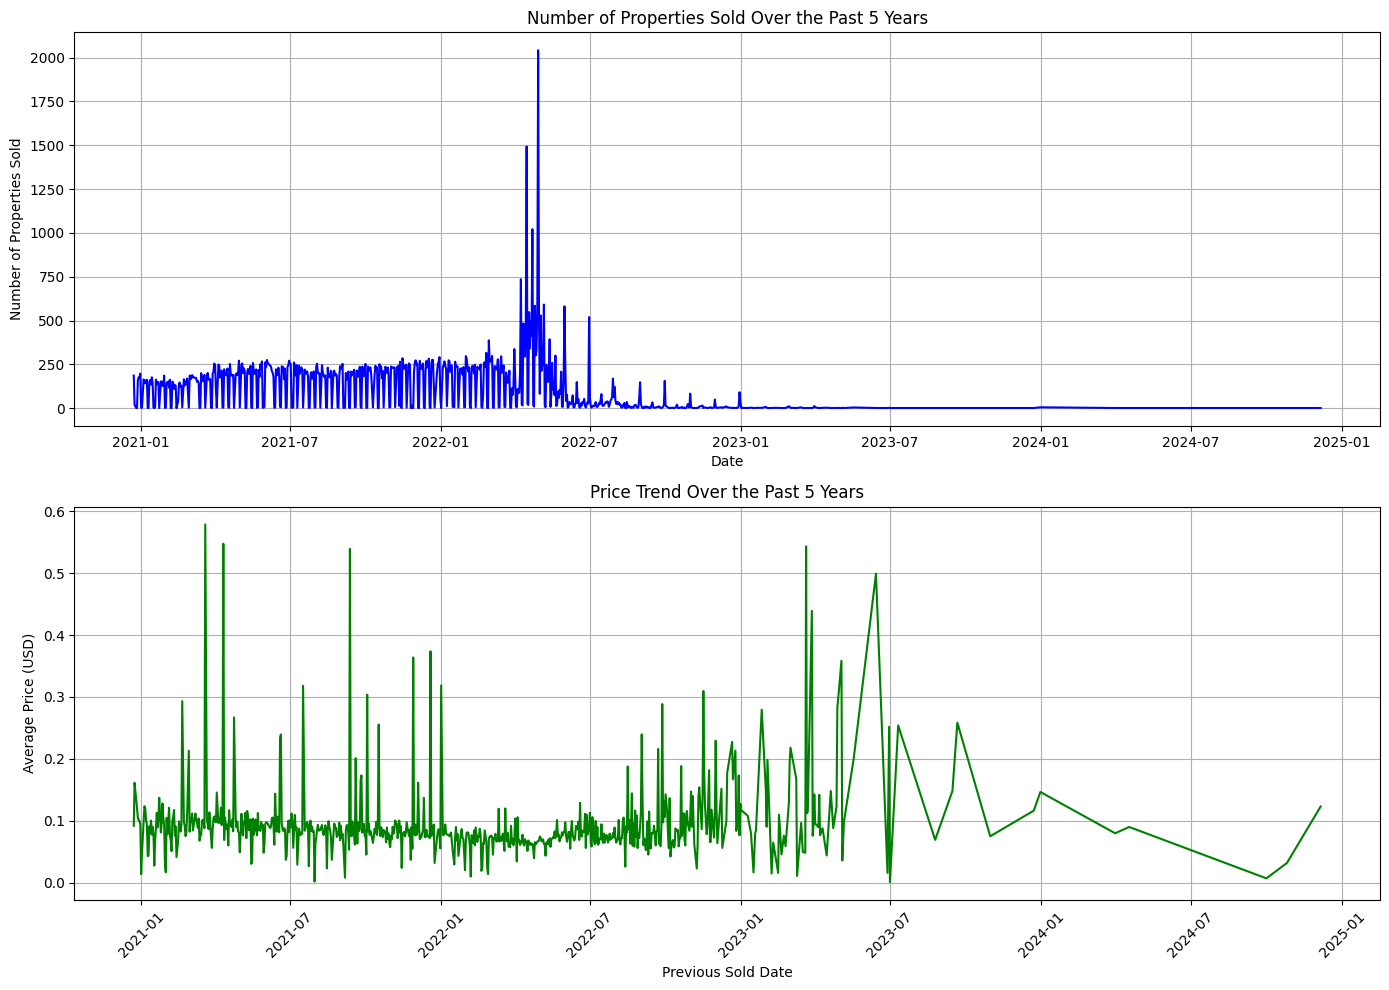

In [0]:
# Define today's date and calculate date 5 years ago
today = pd.Timestamp.today()
five_years_ago = today - pd.DateOffset(years=5)

# Filter plot_df for the past five years
plot_recent_df = plot_df[(plot_df['prev_sold_date'] >= five_years_ago) & (df['prev_sold_date'] <= today)]

# Count number of sales per day
sales_trend = plot_recent_df.groupby('prev_sold_date').size().reset_index(name='sales_count')

# Filter for dates in the past 5 years
recent_df = df[(df['prev_sold_date'] >= five_years_ago) & (df['prev_sold_date'] <= today)]

# Remove unrealistic prices (e.g., under $10,000 or over $5 million)
filtered_recent_df = recent_df[(recent_df['price'] >= 10000) & (recent_df['price'] <= 5000000)]

# Normalize the price column using MinMaxScaler
scaler = MinMaxScaler()
filtered_recent_df['normalized_price'] = scaler.fit_transform(filtered_recent_df[['price']]).ravel()

# Group by date and calculate mean price per day
daily_avg = filtered_recent_df.groupby('prev_sold_date')['price'].mean().reset_index()
daily_avg_norm = filtered_recent_df.groupby('prev_sold_date')['normalized_price'].mean().reset_index()

# To inverse the normalization
original_prices = scaler.inverse_transform(daily_avg_norm[['normalized_price']])

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Plot 1: Sales count over time
axs[0].plot(sales_trend['prev_sold_date'], sales_trend['sales_count'], color='blue')
axs[0].set_title("Number of Properties Sold Over the Past 5 Years")
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Number of Properties Sold")
axs[0].grid(True)

# Plot 2: Average price over the past 5 years
axs[1].plot(daily_avg['prev_sold_date'], daily_avg_norm['normalized_price'], color='green')
axs[1].set_title("Price Trend Over the Past 5 Years")
axs[1].set_xlabel("Previous Sold Date")
axs[1].set_ylabel("Average Price (USD)")
axs[1].grid(True)

# Rotate x-axis labels for the second plot
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Brief Report

Over the past five years, the report highlights the days with highest and lowest number of properties sold, as well as the higheset and lowest average sold price.

In [0]:
# Count number of properties sold per day
daily_sales_count = plot_recent_df.groupby('prev_sold_date').size().reset_index(name='sales_count')

# Find the date with the highest number of sales
highest_sales_day = daily_sales_count.loc[daily_sales_count['sales_count'].idxmax()]

# Find the date with the lowest number of sales (greater than 0)
lowest_sales_day = daily_sales_count[daily_sales_count['sales_count'] > 0].loc[daily_sales_count['sales_count'].idxmin()]

# Display results
print("📈 Day with the highest number of property sales:")
print("Date:", highest_sales_day['prev_sold_date'].date())
print("Number of Sales:", highest_sales_day['sales_count'])

print("\n📉 Day with the lowest number of property sales (excluding 0):")
print("Date:", lowest_sales_day['prev_sold_date'].date())
print("Number of Sales:", lowest_sales_day['sales_count'])

# Group by date and calculate average sold price
daily_avg_price = recent_df.groupby('prev_sold_date')['price'].mean().reset_index()

# Drop any NaNs if present
daily_avg_price.dropna(subset=['price'], inplace=True)

# Find the date with the highest average price
highest_avg = daily_avg_price.loc[daily_avg_price['price'].idxmax()]

# Find the date with the lowest average price
lowest_avg = daily_avg_price.loc[daily_avg_price['price'].idxmin()]

# Display results
print("\n📈 Highest average sold price:")
print("Date:", highest_avg['prev_sold_date'].date())
print("Average Price: ${:,.2f}".format(highest_avg['price']))

print("\n📉 Lowest average sold price:")
print("Date:", lowest_avg['prev_sold_date'].date())
print("Average Price: ${:,.2f}".format(lowest_avg['price']))

📈 Day with the highest number of property sales:
Date: 2022-04-29
Number of Sales: 2042

📉 Day with the lowest number of property sales (excluding 0):
Date: 2020-12-26
Number of Sales: 1

📈 Highest average sold price:
Date: 2021-03-20
Average Price: $10,581,666.67

📉 Lowest average sold price:
Date: 2023-07-01
Average Price: $15,000.00


### 2-2. Geospatial Analysis

2-2-1. Properties For Sale by State: The map highlights Florida (FL) as having the highest number of properties for sale, identified by a yellow shade. Several states in the eastern U.S., such as Illinois (IL), Georgia (GA), and North Carolina (NC), show relatively high numbers. Among them, New York (NY) stands out with a brighter violet shade, indicating a higher concentration—second only to Florida.

2-2-2. Properties Ready to Build by State: The map highlights Florida as having the highest number of properties ready to build, indicated by a yellow shade. Notably, Texas (TX), with its wide area, shows a relatively high number, represented by a orange shade—similar to Michigan (MI). Additionally, Pennsylvania (PA) displays a brighter orange hue, suggesting a higher concentration compared to the other two.

In [0]:
# Convert full state names to 2-letter abbreviations
def name_to_abbr(state_name):
    state = us.states.lookup(state_name)
    return state.abbr if state else None
    
# Group by state and status, pivot table
status_counts = df.groupby(['state', 'status']).size().unstack(fill_value=0).reset_index()

# Convert 'state' column from full names to abbreviations
status_counts['state'] = status_counts['state'].apply(name_to_abbr)

# Drop rows with invalid or unrecognized states
status_counts.dropna(subset=['state'], inplace=True)

# Create subplots with 1 row, 2 columns
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Properties For Sale by State", "Properties Ready to Build by State"),
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    horizontal_spacing=0.2
    
)

# Choropleth for 'for_sale'
fig.add_trace(
    go.Choropleth(
        locations=status_counts['state'],
        z=status_counts['for_sale'],
        locationmode='USA-states',
        colorbar=dict(title='For Sale', x=0.45), # Move to the left
        showscale=True
    ),
    row=1, col=1
)

# Choropleth for 'ready_to_build'
fig.add_trace(
    go.Choropleth(
        locations=status_counts['state'],
        z=status_counts['ready_to_build'],
        locationmode='USA-states',
        colorbar=dict(title='Ready to Build', x=1.05), # Move to the far right
        showscale=True
    ),
    row=1, col=2
)

# Layout settings
fig.update_layout(
    title_text="Real Estate Status by State",
    geo=dict(scope='usa'), # First map (left)
    geo2=dict(scope='usa'), # Second map (right)
    height=600,
    width=1000,
    #margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()

### 2-4. The housing price between Metropolitan and Micropolitan Areas

2-4-1.Interpretation of Violin Plot

The violin plot shows the distribution of housing prices in Metropolitan (Metro) vs. Micropolitan (Micro) areas. Here's what the shapes and lines represent:

**Violin width**: Represents the density of data points at different price levels (how concentrated the prices are).
**Box inside the violin**: Shows the interquartile range (IQR), with the white dot indicating the median price.
**Whiskers (lines extending from the box)**: Indicate the range of prices (minimum to maximum or a percentile range).

Observations:
| Area Type |	Violin Width |	Whisker Length |	Interpretation |
|-----------|--------------|-----------------|-----------------|
|**Micropolitan**|	Wide	| Short|	Prices are clustered tightly within a narrow range, indicating less variation and more consistency in property prices. |
|**Metropolitan**|	Narrow |	Long |	Prices are more spread out with greater variability, including higher priced properties, indicating a more diverse market. |

Summary:

**Micropolitan areas** have housing prices concentrated around similar values with fewer extreme highs or lows.

**Metropolitan areas** show a wider range of prices, reflecting a diverse housing market with both affordable and luxury homes.

This explains why the Micropolitan violin looks wider and shorter, while the Metropolitan violin is narrower with longer whiskers.


Text(0.5, 1.0, 'Price Comparison: Metropolitan vs. Micropolitan')

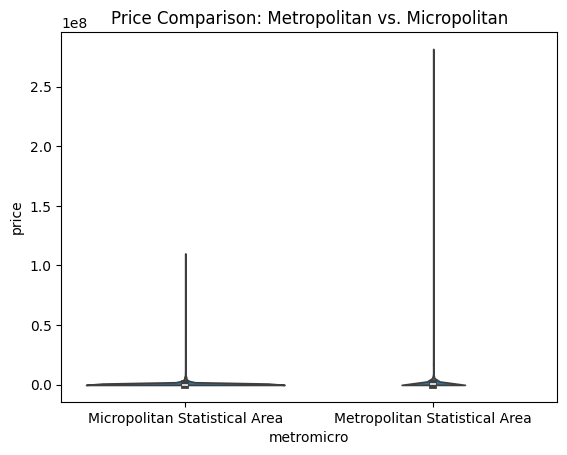

In [0]:
sns.violinplot(data=df_merged, x='metromicro', y='price')
plt.title("Price Comparison: Metropolitan vs. Micropolitan")

2-4-2. Welch’s t-test

While Welch’s t-test shows a statistically significant difference in mean
housing prices between Metropolitan and Micropolitan areas (p < 0.001),
the effect size is small (Cohen’s d = 0.13). This suggests that although
the difference is consistent across a large sample, the magnitude of the
average price gap is modest relative to the overall price variability.


In [0]:
metro_prices = df_merged[df_merged['metromicro'] == 'Metropolitan Statistical Area']['price']
micro_prices = df_merged[df_merged['metromicro'] == 'Micropolitan Statistical Area']['price']

t_stat, p_val = ttest_ind(
    metro_prices,
    micro_prices,
    equal_var=False,
    nan_policy='omit'
)

print(f"T-test result: t={t_stat:.2f}, p={p_val:.2e}")

T-test result: t=61.05, p=0.00e+00


Cohen's d (log price) = 0.55


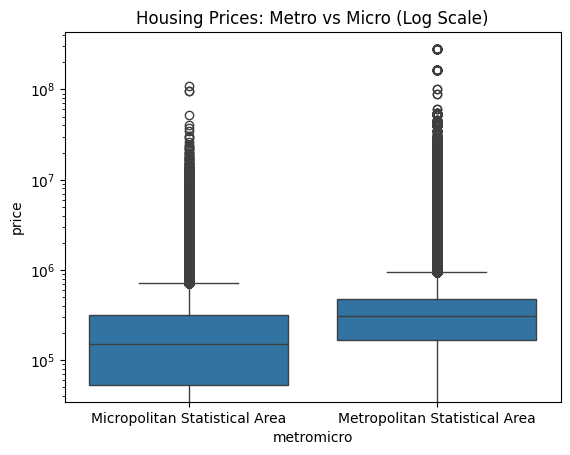

In [0]:
metro_log = np.log1p(metro_prices)
micro_log = np.log1p(micro_prices)

mean_diff = metro_log.mean() - micro_log.mean()
pooled_std = np.sqrt(
    (metro_log.var() + micro_log.var()) / 2
)

cohens_d_log = mean_diff / pooled_std
print(f"Cohen's d (log price) = {cohens_d_log:.2f}")

sns.boxplot(
    x='metromicro',
    y='price',
    data=df_merged
)
plt.yscale('log')
plt.title('Housing Prices: Metro vs Micro (Log Scale)')
plt.show()


2-4-3. Ranking of High-Demand Areas by Median Housing Price (Bar Chart)

Using CBSA titles to identify the most popular (i.e., expensive) housing markets based on median home prices.

The top 10 CBSAs are ranked by their median property price.


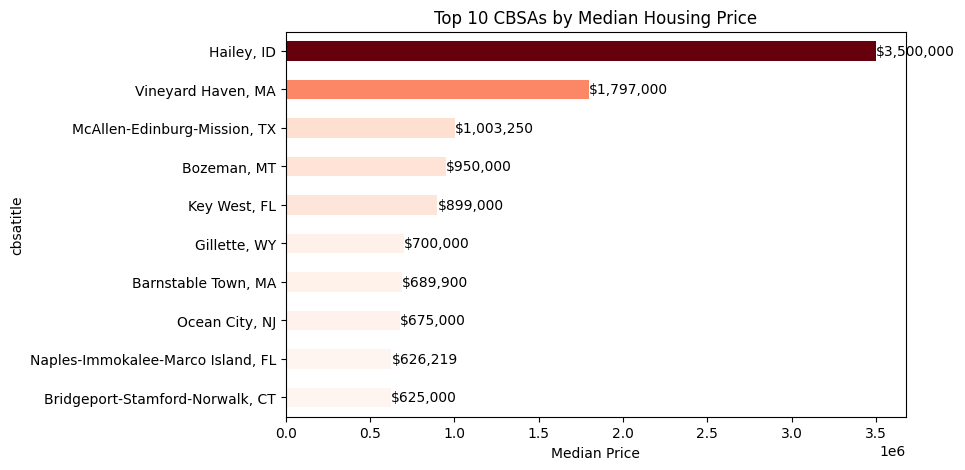

In [0]:
top_cbsa = df_merged.groupby('cbsatitle')['price'].median() \
    .sort_values(ascending=False).head(10)

norm = (top_cbsa - top_cbsa.min()) / (top_cbsa.max() - top_cbsa.min())
colors = [cm.Reds(x) for x in norm]

ax = top_cbsa.plot(kind='barh', figsize=(8, 5), color=colors)
for i, v in enumerate(top_cbsa):
    ax.text(v + 1000, i, f"${int(v):,}", va='center')
    
plt.xlabel("Median Price")
plt.title("Top 10 CBSAs by Median Housing Price")
plt.gca().invert_yaxis()
plt.show()

The analysis of average housing prices by CBSA shows that price differences
are driven more by specific metropolitan areas than by broad metro vs micro
classification. While the overall metro–micro effect is modest, certain
CBSAs exhibit substantially higher average prices.


### 2-5. House Type and Area Analysis

From the plot, we can see that property types in metropolitan areas are more diverse than in micropolitan areas, consistent with the findings in the price comparison. More price ranges are available, offering a wider variety of property types.

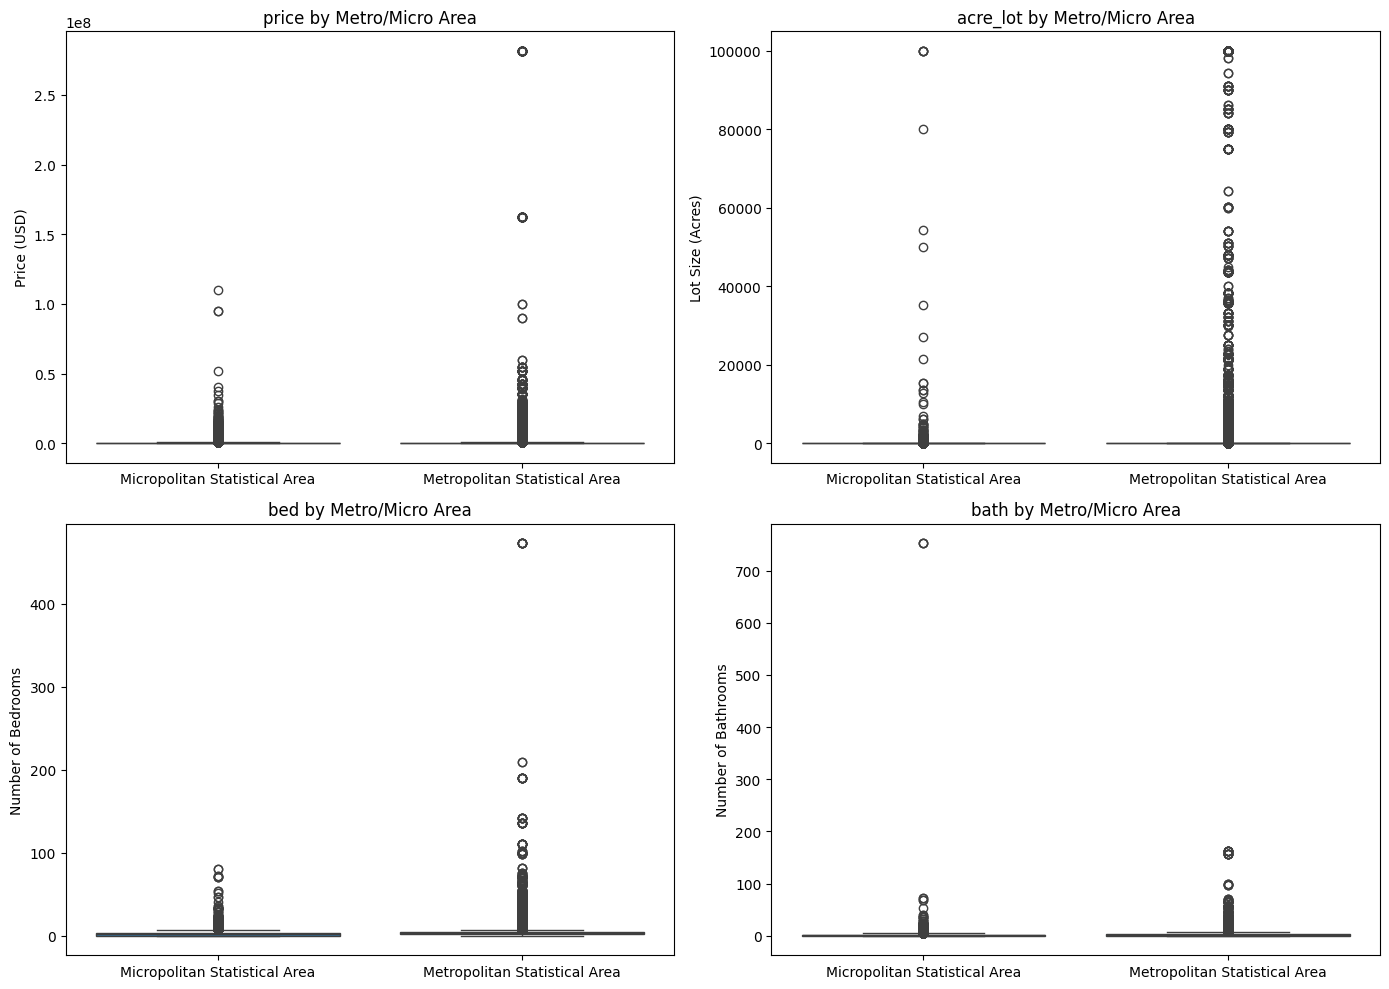

In [0]:
features = ['price', 'acre_lot', 'bed', 'bath']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2 rows, 2 columns

label_dict = {
    'price': 'Price (USD)',
    'acre_lot': 'Lot Size (Acres)',
    'bed': 'Number of Bedrooms',
    'bath': 'Number of Bathrooms'
}

for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]  # Get subplot position
    sns.boxplot(x='metromicro', y=col, data=df_merged, ax=ax)
    ax.set_title(f'{col} by Metro/Micro Area')
    ax.set_xlabel('')  # Optional: clean up x-label
    ax.set_ylabel(label_dict[col])

plt.tight_layout()
plt.show()

### 2-3. Seasonal Analysis (Spring/Summer vs. Fall/Winter) - Heatmaps

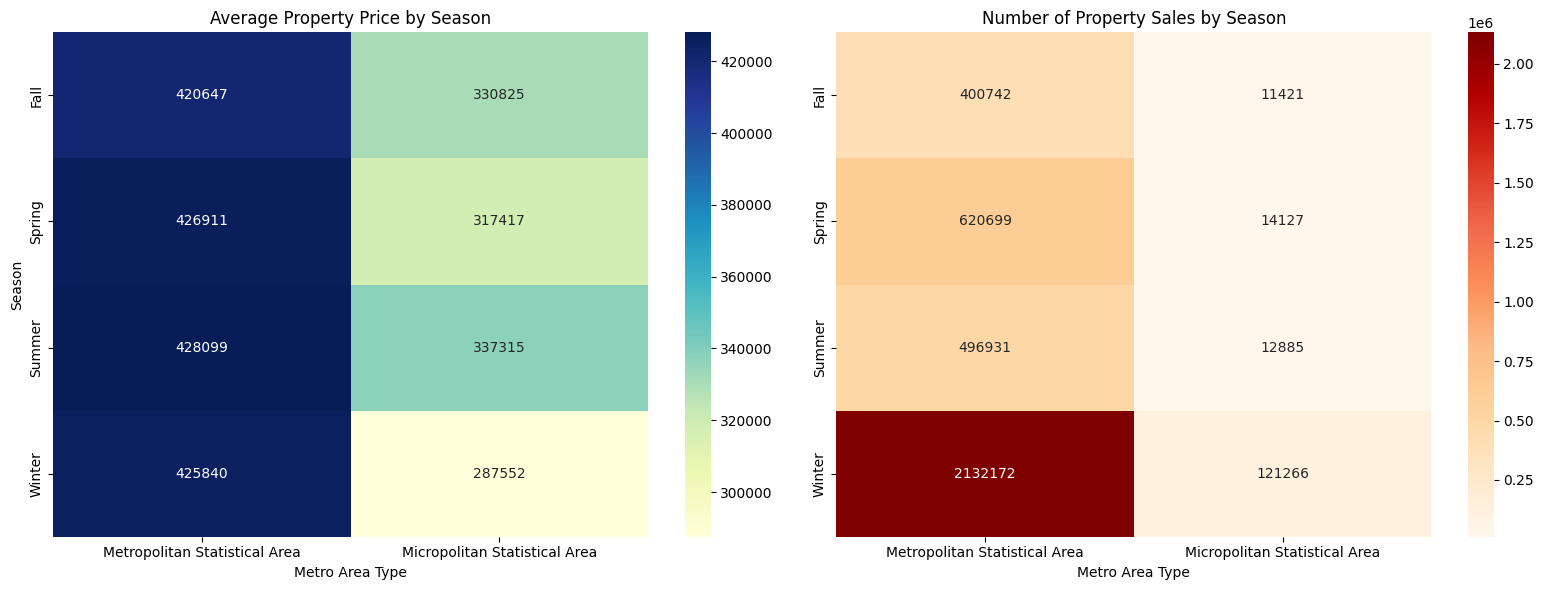

In [0]:
df_merged['prev_sold_date'] = pd.to_datetime(df_merged['prev_sold_date'])

def assign_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

df_merged['season'] = df_merged['prev_sold_date'].dt.month.apply(assign_season)

season_price = df_merged.groupby(['season', 'metromicro'])['price'].mean().unstack()
season_count = df_merged.groupby(['season', 'metromicro']).size().unstack()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# Heatmap 1: Average Price
sns.heatmap(season_price, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Average Property Price by Season")
axes[0].set_xlabel("Metro Area Type")
axes[0].set_ylabel("Season")

# Heatmap 2: Number of Sales
sns.heatmap(season_count, annot=True, fmt="d", cmap="OrRd", ax=axes[1])
axes[1].set_title("Number of Property Sales by Season")
axes[1].set_xlabel("Metro Area Type")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


# 3. One-year house price prediction

### 3-1. Model Performance Overview (RMSE Comparison)

**Interpretation:**

The RMSE values indicate that XGBoost achieves significantly higher predictive accuracy than Random Forest on the test set.  
Specifically, XGBoost's RMSE is approximately $46,684, whereas Random Forest's RMSE is around $70,683.  

This difference suggests that XGBoost is better at capturing non-linear relationships and interactions between features such as zip code, lot size, and the number of bedrooms and bathrooms.  
In contrast, Random Forest, while robust, is less sensitive to high-cardinality categorical features and the log-transformed target variable, resulting in higher prediction errors.

Model Performance Overview

| Model               | Test RMSE (in dollars) |
|--------------------|----------------------|
| XGBoost (F-score)  | $46,683.78           |
| Random Forest (MDI) | $70,682.97           |

Note: Lower RMSE indicates better predictive performance.
<br>
<br>
### 3-2. Comparing Feature Importance: XGBoost F-score vs Random Forest MDI

3-2-1. F-Score

**F-Score** (also known as frequency) is the number of times a feature is used to split the data across all trees in the XGBoost model.

Interpretation:
- **zip_code: 15372.0** → Used **15372 times**.
- **acre_lot: 14592.0** → This feature was used **14592 times** to split nodes across all decision trees.
- **bed: 10510.0** → Used **10510 times**.
- **bath: 9762.0** → Used **9762 times**.
- **season: 6448.0** → Used **6448 times**.
- **metromicro: 2151.0** → Used **2151 times**.

Features with higher F scores contribute more significantly to the model’s decision-making.

3-2-2. MDI 

**MDI (Mean Decrease in Impurity)** measures **how much a feature contributes to reducing the prediction** error across all trees in a Random Forest model.

Higher values indicate that the feature **has a stronger impact on improving the model’s accuracy.**

Interpretation:
- **bath: 0.610** → Contributes **61%** of the total reduction in impurity; most influential feature.
- **zip_code: 0.206** → Contributes **20.6%** of the total impurity reduction.
- **acre_lot: 0.135** → Contributes **13.5%.**
- **bed: 0.040** → Contributes **4.0%.**
- **season: 0.006** → Contributes **0.6%.**
- **metromicro: 0.004** → Contributes **0.4%**; least influential.

**Key Point:**
- Unlike F-score, which counts how often a feature is used to split, MDI reflects **the actual contribution to improving predictions.**
- Features with higher MDI values **have more effect on reducing model error**, even if they are used less frequently in tree splits.

⚠️ Due to Databricks Free Edition runtime limitations, early stopping
parameters are not supported in XGBoost's sklearn API. Model complexity
is controlled via n_estimators and validation-based evaluation instead.


[0]	validation_0-rmse:0.53500
[1]	validation_0-rmse:0.52835
[2]	validation_0-rmse:0.55014
[3]	validation_0-rmse:0.54662
[4]	validation_0-rmse:0.54433
[5]	validation_0-rmse:0.56695
[6]	validation_0-rmse:0.58854
[7]	validation_0-rmse:0.58542
[8]	validation_0-rmse:0.58549
[9]	validation_0-rmse:0.60092
[10]	validation_0-rmse:0.62014
[11]	validation_0-rmse:0.63831
[12]	validation_0-rmse:0.65199
[13]	validation_0-rmse:0.65047
[14]	validation_0-rmse:0.65178
[15]	validation_0-rmse:0.65173
[16]	validation_0-rmse:0.65158
[17]	validation_0-rmse:0.64643
[18]	validation_0-rmse:0.64697
[19]	validation_0-rmse:0.65996
[20]	validation_0-rmse:0.67513
[21]	validation_0-rmse:0.68723
[22]	validation_0-rmse:0.69794
[23]	validation_0-rmse:0.69932
[24]	validation_0-rmse:0.69407
[25]	validation_0-rmse:0.68909
[26]	validation_0-rmse:0.69927
[27]	validation_0-rmse:0.70937
[28]	validation_0-rmse:0.70902
[29]	validation_0-rmse:0.70958
[30]	validation_0-rmse:0.71071
[31]	validation_0-rmse:0.71251
[32]	validation_0-

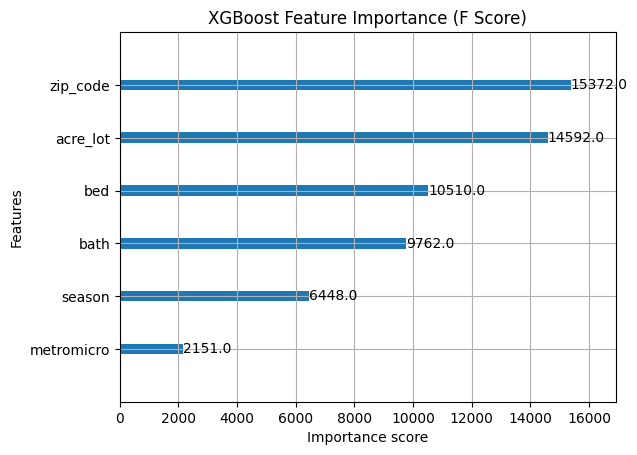

In [0]:
# Step 1: Create year-month feature
df_merged['year_month'] = df_merged['prev_sold_date'].dt.to_period('M').astype(str)

# Step 2: Select features and target
features = ['bed', 'bath', 'acre_lot', 'zip_code', 'season', 'metromicro']
target = 'price'

# Step 3: Drop missing values
df_model = df_merged.dropna(subset=features + [target]).copy()

# Step 4: Label encode categorical features
for col in ['zip_code', 'season', 'metromicro']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Step 5: Time-based split（train / test / val）
train_data = df_model[df_model['prev_sold_date'] < '2024-01-01']
val_data   = df_model[
    (df_model['prev_sold_date'] >= '2024-01-01') &
    (df_model['prev_sold_date'] < '2025-01-01')
]
test_data  = df_model[df_model['prev_sold_date'] >= '2025-01-01']

X_train = train_data[features]
X_val   = val_data[features]
X_test  = test_data[features]

y_train = np.log1p(train_data[target])
y_val   = np.log1p(val_data[target])
y_test  = np.log1p(test_data[target])

# 🔁 Log-transform target
y_train = np.log1p(train_data[target])
y_test = np.log1p(test_data[target])

# Step 6: Train XGBoost model
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# Step 7: Predict and evaluate
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Reverse log1p
y_test_actual = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print(f"✅ Test RMSE (in dollars): ${rmse:,.2f}")

# Step 8: Plot feature importance
plot_importance(model,importance_type='weight', max_num_features=10)
plt.title("XGBoost Feature Importance (F Score)")
plt.show()

🌲 RF Test RMSE (in dollars): $70,682.97
bath          0.610166
zip_code      0.205577
acre_lot      0.134753
bed           0.040316
season        0.005611
metromicro    0.003577
dtype: float64


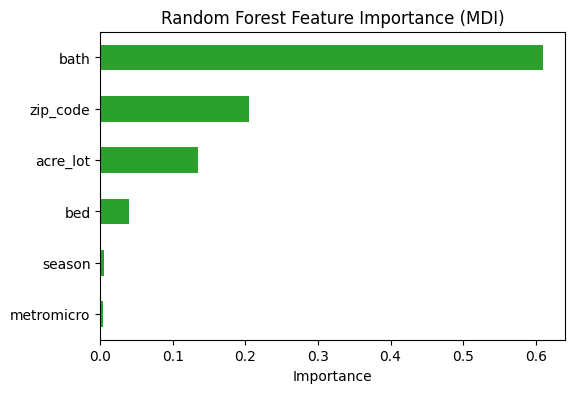

In [0]:
#  Step 9：Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Step 10：
rf_pred_log = rf_model.predict(X_test)

rf_pred = np.expm1(rf_pred_log)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))

print(f"🌲 RF Test RMSE (in dollars): ${rf_rmse:,.2f}")

# Step 11：RF Feature Importance
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(rf_importance)

# Step 12：RF Feature Importance Visualization
plt.figure(figsize=(6, 4))
rf_importance.head(10).plot(kind='barh', color='#2ca02c')
plt.title("Random Forest Feature Importance (MDI)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

XGBoost substantially outperforms Random Forest in terms of predictive accuracy, achieving a test RMSE of $46,684 compared to $70,683 for Random Forest.

Feature importance analysis reveals a clear methodological contrast: XGBoost’s F-score emphasizes frequently used split variables such as zip code, whereas Random Forest’s MDI highlights features that most effectively reduce prediction error, with the number of bathrooms dominating the importance ranking.

Despite these differences, both models consistently identify structural housing attributes—acreage, bedrooms, and bathrooms—as the primary drivers of housing prices, while temporal and regional classification variables play a secondary role.